Exploración de correlación de datos y complejidad.

Importamos la base de datos, junto con librerías para realizar análisis PCA y gráficos.

In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("Effor_index_MASTER.csv")

Estandarizamos ls asignaciones para los niveles de digitalización, primero para una lista de 14 niveles fijos.

In [3]:
mapa_fijo = {
    "nivel 1": 1,
    "nivel 2": 2,
    "nivel 3.1": 3,
    "nivel 3.2": 4,
    "nivel 3.3": 5,
    "nivel 3.4": 6,
    "nivel 3.5": 7,
    "nivel 3.6": 8,
    "nivel 3.7": 9,
    "nivel 3.8": 10,
    "nivel 3.9": 11,
    "nivel 4.1": 12,
    "nivel 4.2": 13,
    "nivel 4.3": 14
}

df["nivel_digitalizacion_numT"] = (
    df["nivel_digitalizacion"]
    .str.lower()
    .str.strip()
    .map(mapa_fijo)
)

Rellenamos valores nulos para ausencia de datos en las columnas de nivel de digitalización y tiempo del trámite.

In [4]:
df["nivel_digitalizacion_num"] = df["nivel_digitalizacion_numT"].fillna(0)

Creamos la variable "suma_N" como la suma del número de formatos y el número de requisitos que contiene el trámite. Además, creamos la variable "costo" que asigna valor de 1 para aquellos trámites que requieren un pago y un 0 si no lo requieren.

In [5]:
# Crear nueva columna con la suma
df["suma_N"] = df["N_FORMATOS_FINAL"] + df["CONTEO_NETO"]

# Columna de existencia de costo
df["costo"] = df["TraCosto"].map({"VERDADERO": 1, "FALSO": 0})

Generamos gráficos tridimensionales para intentar observar correlación de cierto tipo entre las variables.

In [21]:
# Crear gráfico 3D
fig = px.scatter_3d(
    df,
    x="nivel_digitalizacion_num",
    y="suma_N",
    z="Tiempo_en_minutos",
    color="nivel_digitalizacion_num",  # opcional
    title="Relación 3D entre nivel, suma y tiempo"
)

# Guardar como HTML interactivo
fig.write_html("grafico_3d_interactivo.html")

# Mostrar en notebook (opcional)
fig.show()

Generamos una matriz de correlación utilizando el método de Pearson, que supone la existencia de una relación lineal entre las variables y es susceptible a outliers.

In [6]:
corr = df[["nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="pearson")
print(corr.to_string())

                          nivel_digitalizacion_num    suma_N  Tiempo_en_minutos     costo
nivel_digitalizacion_num                  1.000000  0.071855          -0.044140  0.158597
suma_N                                    0.071855  1.000000           0.032983  0.202769
Tiempo_en_minutos                        -0.044140  0.032983           1.000000 -0.047991
costo                                     0.158597  0.202769          -0.047991  1.000000


Podemos observar una muy muy baja correlación entre las variables, por lo que podemos asumir que tal vez sean los outliers o la especificación del tipo lineal. Por ello, usaremos ahora el método de Spearman que no es susceptible a outliers y no supone tipo de relación.

In [7]:
corr = df[["nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="spearman")
print(corr.to_string())

                          nivel_digitalizacion_num    suma_N  Tiempo_en_minutos     costo
nivel_digitalizacion_num                  1.000000  0.150518           0.033946  0.135661
suma_N                                    0.150518  1.000000           0.015834  0.240766
Tiempo_en_minutos                         0.033946  0.015834           1.000000 -0.011917
costo                                     0.135661  0.240766          -0.011917  1.000000


Observando poco más de relación entre las variables, aunque sigue siendo poca. Finalmente, intentando con la correlación por método de Kendall, determina si los valores de las variables tienden a ascender o descender entre sí. Valores cercanos a -1 implica que mientras una sube, la otra baja; valores cercanos a 1 indica que ambas suben o bajan simultáneamente; y valores cercanos a 0 indican que no hay relación directa.

In [8]:
corr = df[["nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="kendall")
print(corr.to_string())

                          nivel_digitalizacion_num    suma_N  Tiempo_en_minutos     costo
nivel_digitalizacion_num                  1.000000  0.119699           0.025350  0.123583
suma_N                                    0.119699  1.000000           0.014367  0.209222
Tiempo_en_minutos                         0.025350  0.014367           1.000000 -0.009984
costo                                     0.123583  0.209222          -0.009984  1.000000


Se puede distinguir que no hay correlación directa entre las variables, por lo que, suponer según las hipóteis que un valor de complejidad "C" sea proporcional a "suma_N", a "tiempo en minutos", e inversamente proporcional a "nivel_digitalización" no implica directamente que C=k_1 x suma_N, C=k_2 x tiempo_en_minutos, etc. donde las "k's" son constantes. Proponer una complejidad con estas características debería contener más que eso.
Ahora generamos gráficos bidimensionales entre variables para observar relación.

<function matplotlib.pyplot.show(close=None, block=None)>

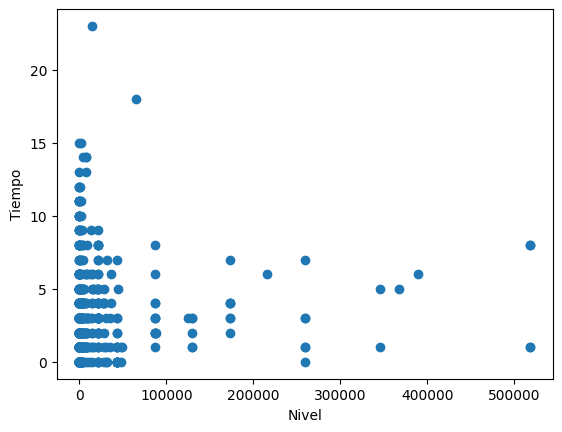

In [25]:
plt.scatter(df["Tiempo_en_minutos"], df["suma_N"])
plt.xlabel("Nivel")
plt.ylabel("Tiempo")

plt.show

Ahora preparamos las variables, en este caso primero sin contar el costo, para estandarizarlas y aplicarles un análisis PCA que otorgará coeficientes para desarrollar variables como combinación lineal de las variables originales.

In [9]:
X = df[[
    "suma_N",
    "Tiempo_en_minutos",
    "nivel_digitalizacion_num"
]].dropna()

from sklearn.preprocessing import StandardScaler

Aplicamos PCA para una sola variable, calculamos también el "pca.explained_variance_ratio" que determina qué porcentaje de los datos originales describe el comportamiento de la nueva variable obtenida por PCA.

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
complejidad = pca.fit_transform(X_scaled)

df.loc[X.index, "Complejidad_PCA"] = complejidad
print("--------------------------")
print(pca.components_)

print(pca.explained_variance_ratio_)

--------------------------
[[ 0.54862426 -0.30677724  0.77775262]]
[0.3509733]


Observando que los valores de los coeficientes describirían una variable influenciada de la siguiente forma: C_1=0.70suma_N+0.39Tiempo_en_minutos+0.59nivel_digitalizacion_num.
Sin embargo, esta elección de variables distingue una descripción baja de 36% de los datos aproximadamente. 
Podemos intentar calcular otra variable para observar la cantidad de datos posiblemente descritos:

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
complejidad = pca.fit_transform(X_scaled)

# 👉 Guardar cada componente en columnas separadas
df.loc[X.index, "PCA_1"] = complejidad[:, 0]
df.loc[X.index, "PCA_2"] = complejidad[:, 1]

print("--------------------------")
print(pca.components_)
print(pca.explained_variance_ratio_)

--------------------------
[[ 0.54862426 -0.30677724  0.77775262]
 [ 0.60934319  0.78366286 -0.1207203 ]]
[0.3509733  0.34414865]


En conjunto, estas dos variables de PCA no describen por completo al conjunto de variables, en conjunto describen aprox 69% de los datos, muy bajo. Consideremos ahora agrupar los subniveles de digitalización 1-14 a los niveles 1, 2, 3 y 4.

In [12]:
def agrupar_nivel(x):
    if x <= 2:
        return x
    elif 3 <= x <= 11:
        return 3
    else:
        return 4

df["nivel_dig_grupo"] = df["nivel_digitalizacion_num"].apply(agrupar_nivel)

X = df[[
    "suma_N",
    "Tiempo_en_minutos",
    "nivel_dig_grupo",
]].dropna()

from sklearn.preprocessing import StandardScaler

Realizamos de nuevo el PCA para una variable y la normalizamos:

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
complejidad = pca.fit_transform(X_scaled)

df.loc[X.index, "Complejidad_PCA"] = complejidad
print("--------------------------")
print(pca.components_)

print(pca.explained_variance_ratio_)
print("--------------------------")

df["Complejidad_PCA_norm"] = (
    (df["Complejidad_PCA"] - df["Complejidad_PCA"].min()) /
    (df["Complejidad_PCA"].max() - df["Complejidad_PCA"].min())
)

df[["Complejidad_PCA_norm", "suma_N", "Tiempo_en_minutos", "nivel_dig_grupo"]].sort_values("Complejidad_PCA_norm")

--------------------------
[[ 0.68307295 -0.0993358   0.72356323]]
[0.36501945]
--------------------------


,Complejidad_PCA_norm,suma_N,Tiempo_en_minutos,nivel_dig_grupo
406,0.000000,0,47520.0,0.0
566,0.001078,0,43200.0,0.0
472,0.001078,0,43200.0,0.0
564,0.001078,0,43200.0,0.0
344,0.006469,0,21600.0,0.0
...,...,...,...,...
650,NaN,3,NaN,0.0
654,NaN,1,NaN,0.0
657,NaN,3,NaN,0.0
658,NaN,3,NaN,0.0


Podemos determinar que los valores de los coeficientes no cambiaron demasiado al modificar la agrupación de los niveles de digitalización. El valor de los datos explicados tampoco y podemos suponer que el valor de una nueva variable PCA será muy similar. Además, la variabilidad explicada es casi del 36% de los datos, muy bajo. Ahora vamos a considerar la variable "costo" que determina si un trámite tiene cierto costo para desarrollarse; tomaremos los 14 niveles de digitalización para abarcar la mayor variedad posible.

In [14]:
X = df[[
    "suma_N",
    "Tiempo_en_minutos",
    "nivel_digitalizacion_num",
    "costo"
]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
pca.fit(X_scaled)
print(pca.explained_variance_ratio_)

print(pca.components_)

components = pca.fit_transform(X_scaled)

df.loc[X.index, "PC1"] = components[:, 0]
df.loc[X.index, "PC2"] = components[:, 1]
df.loc[X.index, "PC3"] = components[:, 2]

[0.30755728 0.25829063 0.22977844]
[[ 0.51899416 -0.16254332  0.51658331  0.66133684]
 [ 0.49944253  0.82420807 -0.26625558  0.01860618]
 [-0.41541643  0.49692748  0.7494346  -0.13725905]]


Observamos que estas tres variables de PCA, en conjunto, aportan el 78% de la información. Dada la relevancia que indican en sus coeficientes a las variables propuestas, podemos suponer que se trata de distintos tipos de "complejidad" como interpretación. La primera forma le da mayor peso al costo, junto a los requisitos y digitalización, por lo que podemos suponer una complejidad económica enfocada en precios. La segunda forma le da mayor peso al tiempo y a los requisitos, una evidente complejidad burocrática debida a la tardanza del trámite y sus trabas. La tercera le da más peso a digitalización y tiempo, una extraña combinación de complejidad administrativa. Podemos proponer que la complejidad se obtiene de la combinación lineal de estas complejidades cuyos coeficientes son las varianzas de cada una. Entonces: 

In [15]:
df["Complejidad_total"] = (
    0.324 * df["PC1"] +
    0.253 * df["PC2"] +
    0.230 * df["PC3"]
)

min_val = df["Complejidad_total"].min()
max_val = df["Complejidad_total"].max()

df["Complejidad_norm"] = (
    df["Complejidad_total"] - min_val
) / (max_val - min_val)

Podemos crear un gráfico 3D de las variables coloreando las respectivas complejidades correspondientes de cada punto:

In [16]:
fig = px.scatter_3d(
    df,
    x="suma_N",
    y="Tiempo_en_minutos",
    z="nivel_digitalizacion_num",
    color="Complejidad_norm"
)

fig.show()

Podemos notar que, convenientemente, los trámites más complejos se encuentran en los extremos, siendo más notorio en mayores tiempos. La existencia de outliers en la variable tiempo puede estar influyendo en la elección de la complejidad. Estudiamos las correlaciones de esta nueva complejidad con las variables, por los tres métodos.

In [17]:
CorrC3 = df[["Complejidad_norm","nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="spearman")
print(CorrC3.to_string())

CorrC3P = df[["Complejidad_norm","nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="pearson")
print(CorrC3P.to_string())

CorrC3P = df[["Complejidad_norm","nivel_digitalizacion_num", "suma_N", "Tiempo_en_minutos","costo"]].corr(method="kendall")
print(CorrC3P.to_string())

                          Complejidad_norm  nivel_digitalizacion_num    suma_N  Tiempo_en_minutos     costo
Complejidad_norm                  1.000000                  0.526025  0.532905           0.271065  0.574715
nivel_digitalizacion_num          0.526025                  1.000000  0.150518           0.033946  0.135661
suma_N                            0.532905                  0.150518  1.000000           0.015834  0.240766
Tiempo_en_minutos                 0.271065                  0.033946  0.015834           1.000000 -0.011917
costo                             0.574715                  0.135661  0.240766          -0.011917  1.000000
                          Complejidad_norm  nivel_digitalizacion_num    suma_N  Tiempo_en_minutos     costo
Complejidad_norm                  1.000000                  0.596806  0.505407           0.517758  0.484859
nivel_digitalizacion_num          0.596806                  1.000000  0.071855          -0.044140  0.158597
suma_N                      

Podemos notar que Spearman y Kendall distinguen baja correlación entre esta complejidad y el tiempo de los trámites. Los tres métodos destacan gran relación entre las otras variables, siendo mejor en el de Pearson que supone relación lineal. Llegando a graficar las tres componentes de PCA asignadas a cada punto de variables:

In [18]:
fig = px.scatter_3d(
    df,
    x=df["PC1"],
    y=df["PC2"],
    z=df["PC3"]
)

fig.show()

Podemos explorar otros ajustes. En este análisis se estipula la utilización de 14 grupos de digitalización para describir mejor la situación real. Distingue el método PCA y cómo correlacionar a las variables.